In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (454902, 30)
X_test:  (56962, 30)


In [3]:
# Definir la validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4]:
# Regresión Logística
print("Entrenando Regresión Logística...")

params_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "saga"]
}

lr = LogisticRegression(max_iter=1000, random_state=42)

grid_lr = GridSearchCV(
    lr, params_lr,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_lr.best_params_}")
print(f"Mejor ROC-AUC: {grid_lr.best_score_:.4f}")

Entrenando Regresión Logística...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros: {'C': 10, 'solver': 'lbfgs'}
Mejor ROC-AUC: 0.9916


In [5]:
# Random Forest
print("\nEntrenando Random Forest...")

params_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    rf, params_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_rf.best_params_}")
print(f"Mejor ROC-AUC en CV: {grid_rf.best_score_:.4f}")


Entrenando Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores parámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Mejor ROC-AUC en CV: 1.0000


ROC-AUC de 1.0000 en Random Forest es sospechoso. Un modelo perfecto casi nunca existe en la realidad.   
Lo más probable es overfitting — el modelo ha memorizado los datos de entrenamiento en lugar de aprender patrones generales. Esto puede pasar con max_depth: None porque los árboles crecen sin límite hasta memorizar cada ejemplo.  
Lo veremos claramente cuando evaluemos contra el test. Si en test baja mucho, confirmaremos el overfitting.

In [6]:
# XGBoost
print("\nEntrenando XGBoost...")

params_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1]
}

xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric="auc",
    verbose=0
)

grid_xgb = GridSearchCV(
    xgb_model, params_xgb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_xgb.best_params_}")
print(f"Mejor ROC-AUC en CV: {grid_xgb.best_score_:.4f}")


Entrenando XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Mejor ROC-AUC en CV: 1.0000


Mismo resultado que Random Forest — 1.0000. Esto ya no es casualidad.  
Lo que está pasando es que con 454.000 filas balanceadas por SMOTE, estos modelos potentes están memorizando los patrones sintéticos generados. No es necesariamente malo — lo importante es cómo se comportan con el test real.

In [7]:
# LightGBM
print("\nEntrenando LightGBM...")

params_lgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1]
}

lgb_model = lgb.LGBMClassifier(
    random_state=42,
    verbose=-1
)

grid_lgb = GridSearchCV(
    lgb_model, params_lgb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_lgb.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_lgb.best_params_}")
print(f"Mejor ROC-AUC en CV: {grid_lgb.best_score_:.4f}")


Entrenando LightGBM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Mejor ROC-AUC en CV: 1.0000


In [8]:
# Evaluación de todos los modelos contra el test

modelos = {
    "Regresión Logística": grid_lr,
    "Random Forest":       grid_rf,
    "XGBoost":             grid_xgb,
    "LightGBM":            grid_lgb
}

resultados = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    reporte = classification_report(y_test, y_pred, output_dict=True)
    
    resultados.append({
        "Modelo":     nombre,
        "ROC-AUC":    round(auc, 4),
        "Precision":  round(reporte["1"]["precision"], 4),
        "Recall":     round(reporte["1"]["recall"], 4),
        "F1-Score":   round(reporte["1"]["f1-score"], 4),
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

             Modelo  ROC-AUC  Precision  Recall  F1-Score
Regresión Logística   0.9712     0.0588  0.9184    0.1106
      Random Forest   0.9615     0.8617  0.8265    0.8438
            XGBoost   0.9811     0.6204  0.8673    0.7234
           LightGBM   0.9790     0.6364  0.8571    0.7304


## Evaluación de modelos contra el test

| Modelo | ROC-AUC | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Regresión Logística | 0.9712 | 0.0588 | 0.9184 | 0.1106 |
| Random Forest | 0.9615 | 0.8617 | 0.8265 | 0.8438 |
| XGBoost | 0.9811 | 0.6204 | 0.8673 | 0.7234 |
| LightGBM | 0.9790 | 0.6364 | 0.8571 | 0.7304 |

### Análisis de resultados

**Regresión Logística** — Recall muy alto (0.9184), detecta el 91% de los fraudes reales.
Sin embargo, su Precision es extremadamente baja (0.0588): el 94% de sus alertas son falsas alarmas.
Demasiado ruidoso para producción.

**Random Forest** — El más equilibrado. Mejor F1-Score (0.8438) con buena Precision (0.8617)
y Recall (0.8265). Sólido y fiable.

**XGBoost y LightGBM** — Resultados muy similares entre sí. Buen Recall (~0.87)
pero Precision moderada (~0.63). Margen de mejora con ajuste de umbral.

### Conclusión

| Objetivo | Mejor modelo |
|---|---|
| Detectar máximos fraudes (aunque haya falsas alarmas) | Regresión Logística |
| Equilibrio precisión/recall | Random Forest |
| Balance general con margen de mejora | XGBoost / LightGBM |

> En detección de fraude el **Recall es la métrica más crítica** — un fraude no detectado
> es mucho más costoso que una falsa alarma. Sin embargo, una Precision de 0.05
> como la de Regresión Logística es inviable en producción.
>
> **Siguiente paso:** ajuste de umbral (threshold tuning) sobre XGBoost y LightGBM
> para mejorar el Recall sin sacrificar demasiada Precision. No lo hacemos sobre todos porque Regresión Logística ya tiene un Recall muy alto pero el problema es la Precisión. Bajar el umbral la empeoraría aún más. Y sobre el Random Forest ya está equilibrada. Tiene el mejor F1, no necesita ajuste. 

In [9]:
# Función para encontrar el umbral óptimo.
def encontrar_umbral_optimo(y_test, y_prob, modelo_nombre):
    umbrales = np.arange(0.1, 0.9, 0.01)
    resultados = []

    for umbral in umbrales:
        y_pred = (y_prob >= umbral).astype(int)
        resultados.append({
            "umbral":    round(umbral, 2),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred),
            "f1":        f1_score(y_test, y_pred)
        })

    df_umbrales = pd.DataFrame(resultados)
    mejor = df_umbrales.loc[df_umbrales["f1"].idxmax()]

    print(f"\n{modelo_nombre}")
    print(f"  Umbral óptimo: {mejor['umbral']}")
    print(f"  Precision:     {mejor['precision']:.4f}")
    print(f"  Recall:        {mejor['recall']:.4f}")
    print(f"  F1-Score:      {mejor['f1']:.4f}")

    return df_umbrales, mejor

In [10]:
# Obtenemos las probabilidades de cada modelo
prob_xgb = grid_xgb.predict_proba(X_test)[:, 1]
prob_lgb = grid_lgb.predict_proba(X_test)[:, 1]

# Encontramos el umbral óptimo para cada uno
df_xgb, mejor_xgb = encontrar_umbral_optimo(y_test, prob_xgb, "XGBoost")
df_lgb, mejor_lgb = encontrar_umbral_optimo(y_test, prob_lgb, "LightGBM")


XGBoost
  Umbral óptimo: 0.85
  Precision:     0.8367
  Recall:        0.8367
  F1-Score:      0.8367

LightGBM
  Umbral óptimo: 0.8
  Precision:     0.8384
  Recall:        0.8469
  F1-Score:      0.8426


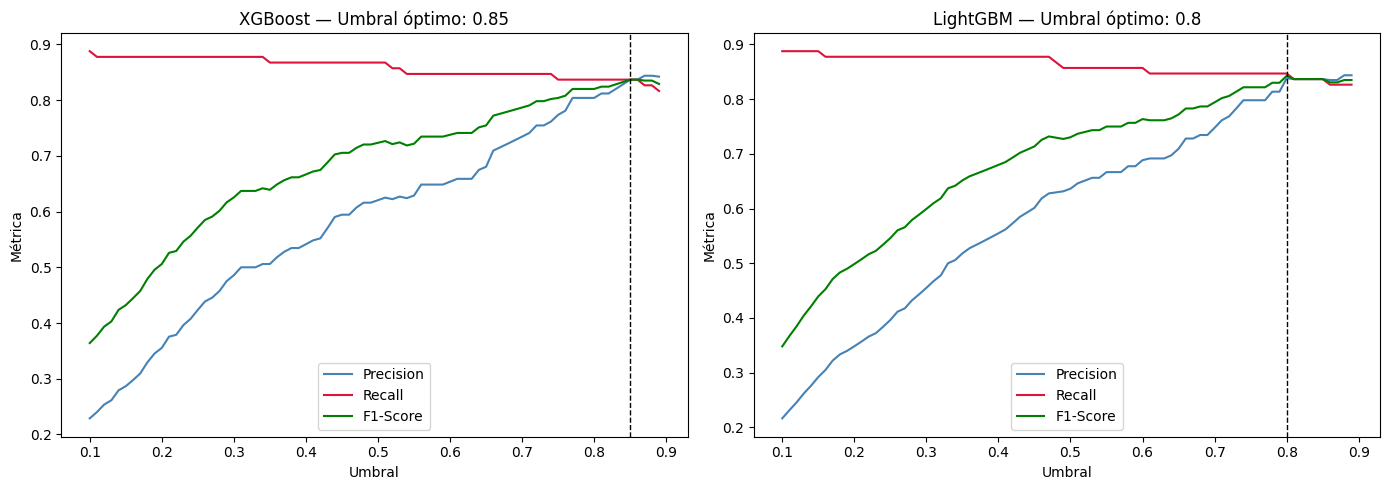

In [13]:
# Visualización 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_u, mejor, nombre in [
    (axes[0], df_xgb, mejor_xgb, "XGBoost"),
    (axes[1], df_lgb, mejor_lgb, "LightGBM")
]:
    ax.plot(df_u["umbral"], df_u["precision"], label="Precision", color="steelblue")
    ax.plot(df_u["umbral"], df_u["recall"],    label="Recall",    color="crimson")
    ax.plot(df_u["umbral"], df_u["f1"],        label="F1-Score",  color="green")
    ax.axvline(x=mejor["umbral"], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{nombre} — Umbral óptimo: {mejor['umbral']}")
    ax.set_xlabel("Umbral")
    ax.set_ylabel("Métrica")
    ax.legend()

plt.tight_layout()
plt.savefig("../notebooks/images/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

## Threshold Tuning — XGBoost y LightGBM

El umbral por defecto de 0.5 es arbitrario. Ajustándolo encontramos el punto
donde el F1-Score es máximo, equilibrando Precision y Recall.

### Resultados antes y después del ajuste

| Modelo | Umbral | Precision | Recall | F1 |
|---|---|---|---|---|
| XGBoost (default) | 0.50 | 0.6204 | 0.8673 | 0.7234 |
| XGBoost (optimizado) | 0.85 | 0.8367 | 0.8367 | 0.8367 |
| LightGBM (default) | 0.50 | 0.6364 | 0.8571 | 0.7304 |
| LightGBM (optimizado) | 0.80 | 0.8384 | 0.8469 | 0.8426 |

### Comparativa final de todos los modelos

| Modelo | Umbral | Precision | Recall | F1 |
|---|---|---|---|---|
| Regresión Logística | 0.50 | 0.0588 | 0.9184 | 0.1106 |
| Random Forest | 0.50 | 0.8617 | 0.8265 | 0.8438 |
| XGBoost | 0.85 | 0.8367 | 0.8367 | 0.8367 |
| **LightGBM** | **0.80** | **0.8384** | **0.8469** | **0.8426** |

### Conclusión

**LightGBM con umbral 0.80 es el modelo ganador:**
- Mejor Recall (0.8469) — detecta el 84.7% de los fraudes reales
- F1-Score prácticamente igual al Random Forest (0.8426 vs 0.8438)
- Umbral más bajo que XGBoost — más sensible a detectar fraudes

> **Trade-off clave:** subir el umbral aumenta la Precision pero baja el Recall.
> En detección de fraude priorizamos el Recall — un fraude no detectado
> es siempre más costoso que una falsa alarma.

### Modelo seleccionado para producción
**LightGBM** con umbral de clasificación **0.80**
______

In [14]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

# Guardamos el modelo y el umbral óptimo juntos en un diccionario
modelo_final = {
    "modelo": grid_lgb.best_estimator_,
    "umbral": mejor_lgb["umbral"]
}

with open("../models/lightgbm_fraud.pkl", "wb") as f:
    pickle.dump(modelo_final, f)

print("Modelo guardado correctamente en models/lightgbm_fraud.pkl")
print(f"Modelo: LightGBM")
print(f"Umbral: {mejor_lgb['umbral']}")

Modelo guardado correctamente en models/lightgbm_fraud.pkl
Modelo: LightGBM
Umbral: 0.8
